In [1]:
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import matplotlib.cm as cm

In [2]:
from matplotlib import rc
rc('text', usetex=True)
rc('font', family='serif')
rc('mathtext', default='sf')
rc("lines", markeredgewidth=1)
rc("lines", linewidth=1)
rc('axes', titlesize=24) #24
rc('axes', labelsize=24) #24
rc("axes", linewidth=1) #2)
rc('axes', labelpad=20) #24)
rc('xtick', labelsize=16)
rc('ytick', labelsize=16)
rc('legend', fontsize=16)
rc('ytick', right='True',direction= 'in')
rc('xtick', top='True',direction= 'in')
rc('xtick.major', pad=15) #8)
rc('ytick.major', pad=15) #8)
rc('xtick.major', size=12) #8)
rc('ytick.major', size=12) #8)
rc('xtick.minor', size=7) #8)
rc('ytick.minor', size=7) #8)
rc('figure', titlesize=27) #24)

def set_tick_sizes(ax, major, minor):
    for l in ax.get_xticklines() + ax.get_yticklines():
        l.set_markersize(major)
    for tick in ax.xaxis.get_minor_ticks() + ax.yaxis.get_minor_ticks():
        tick.tick1line.set_markersize(minor)
        tick.tick2line.set_markersize(minor)
    ax.xaxis.LABELPAD=10.
    ax.xaxis.OFFSETTEXTPAD=10.

In [3]:
df = pd.read_csv('../src/data/SXS_Parameters_non-spinning.csv')
mask = df['catalog'] == 'SXS'
sxs_ids = df.loc[mask, 'ID'].astype(int).values
sxs_ids = [str(i).zfill(4) for i in sxs_ids]
nu = df.loc[mask, 'nu'].values

In [4]:
c3A, c3p, c4p, c2A, c2p = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
c3A_err, c3p_err, c4p_err, c2A_err, c2p_err = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
full_data = []
for i, sxs_id in enumerate(sxs_ids):
    try:
        data = np.loadtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}/Algorithm/posterior.dat')[:,[1,2,3,4,5]]
        c3A[i], c3p[i], c4p[i], c2A[i], c2p[i] = np.median(data, axis=0)
        c3A_err[i], c3p_err[i], c4p_err[i], c2A_err[i], c2p_err[i] = np.std(data, axis=0)
        full_data.append(data)
    except:
        continue

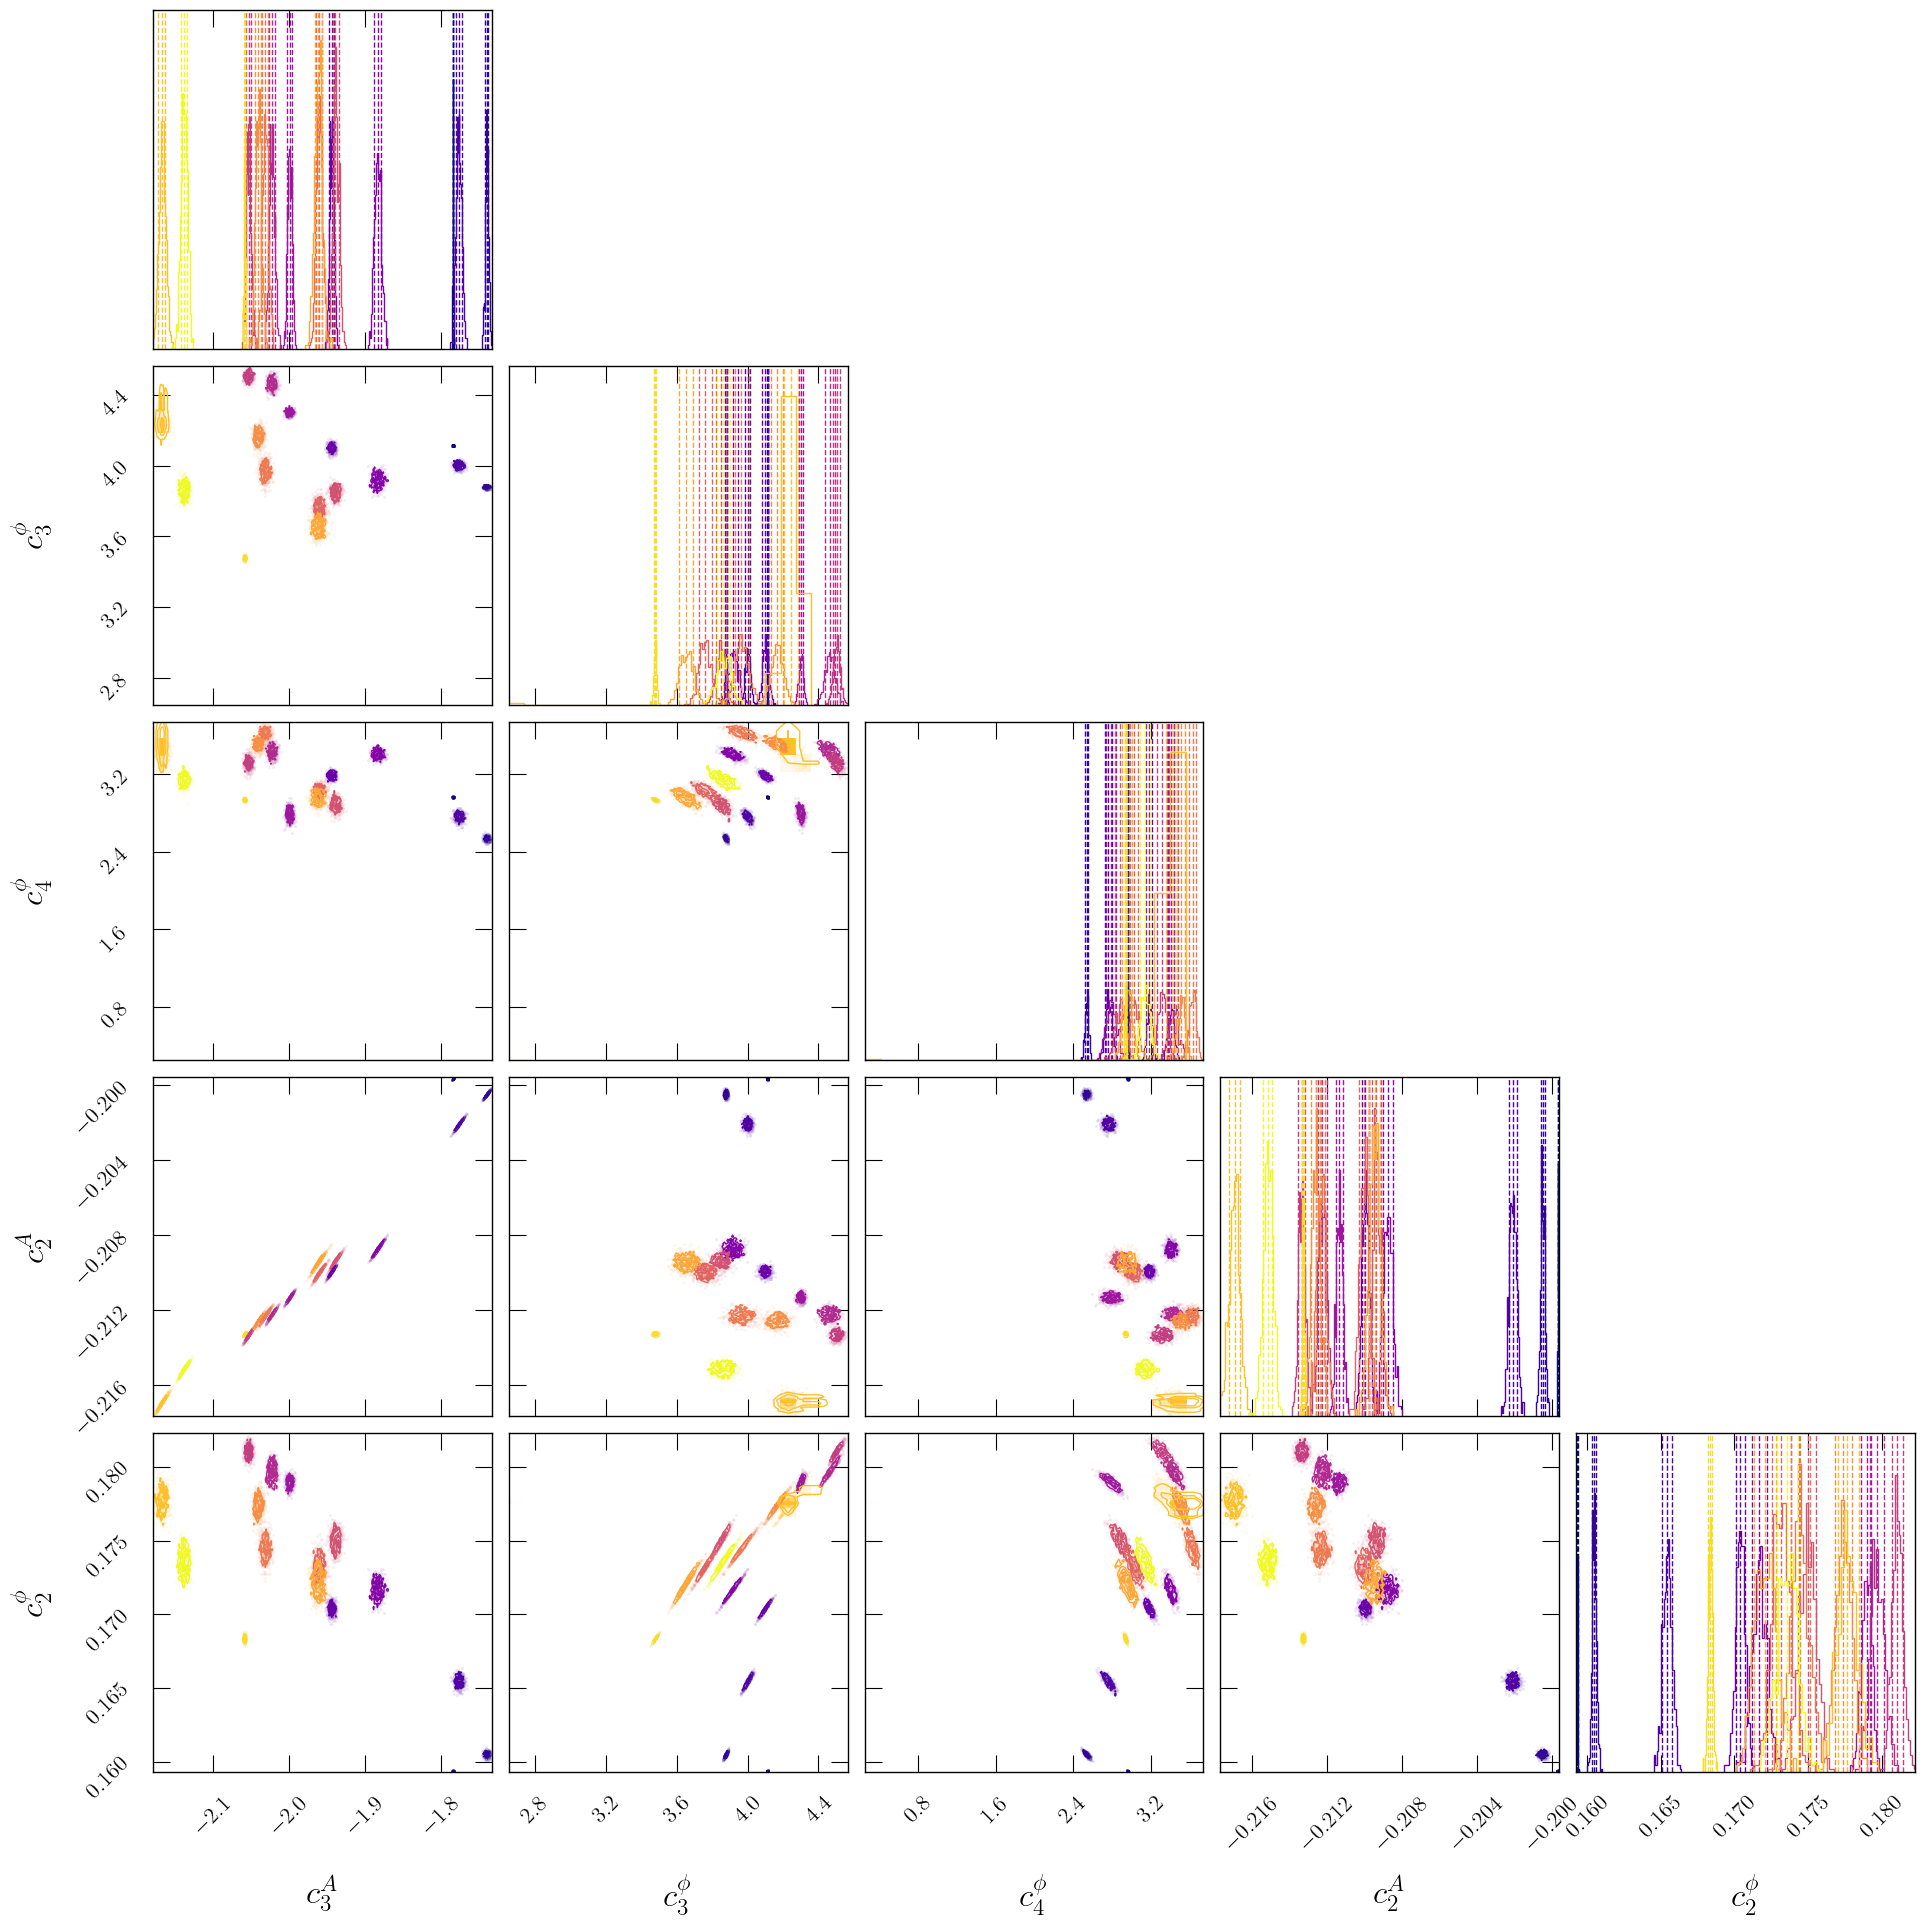

In [5]:
colors = [matplotlib.colormaps.get_cmap('plasma')(i) for i in np.linspace(0, 1, len(sxs_ids))]
ylabels = ['$c_3^A$', '$c_3^{\\phi}$', '$c_4^{\\phi}$', '$c_2^A$', '$c_2^{\\phi}$']
fig = corner.corner(full_data[0],
                    labels=ylabels,
                    color=colors[0],
                    quantiles=(0.16, 0.5, 0.84))
for i, data in enumerate(full_data):
    if i == 0:
        continue
    if c3A[i] < -4:
        continue
    fig = corner.corner(data,
                        labels=ylabels,
                        color=colors[i],
                        quantiles=(0.16, 0.5, 0.84),
                        fig=fig)
fig.set_size_inches(20, 20)
plt.show()

In [6]:
p2Anu, cov_p2A = np.polyfit(nu, c2A, 1, w=1/c2A_err, cov=True)
p3Anu, cov_p3A = np.polyfit(nu, c3A, 1, w=1/c3A_err, cov=True)
p2pnu, cov_p2p = np.polyfit(nu, c2p, 1, w=1/c2p_err, cov=True)
p3pnu, cov_p3p = np.polyfit(nu, c3p, 1, w=1/c3p_err, cov=True)
p4pnu, cov_p4p = np.polyfit(nu, c4p, 1, w=1/c4p_err, cov=True)

print('p2A:', p2Anu)
print('p3A:', p3Anu)
print('p2p:', p2pnu)
print('p3p:', p3pnu)
print('p4p:', p4pnu)

p2A: [ 0.08442713 -0.22085849]
p3A: [ 1.69280657 -2.20606118]
p2p: [-0.0833614   0.18029905]
p3p: [2.3513975  3.51870043]
p4p: [-0.30999215  3.03909683]


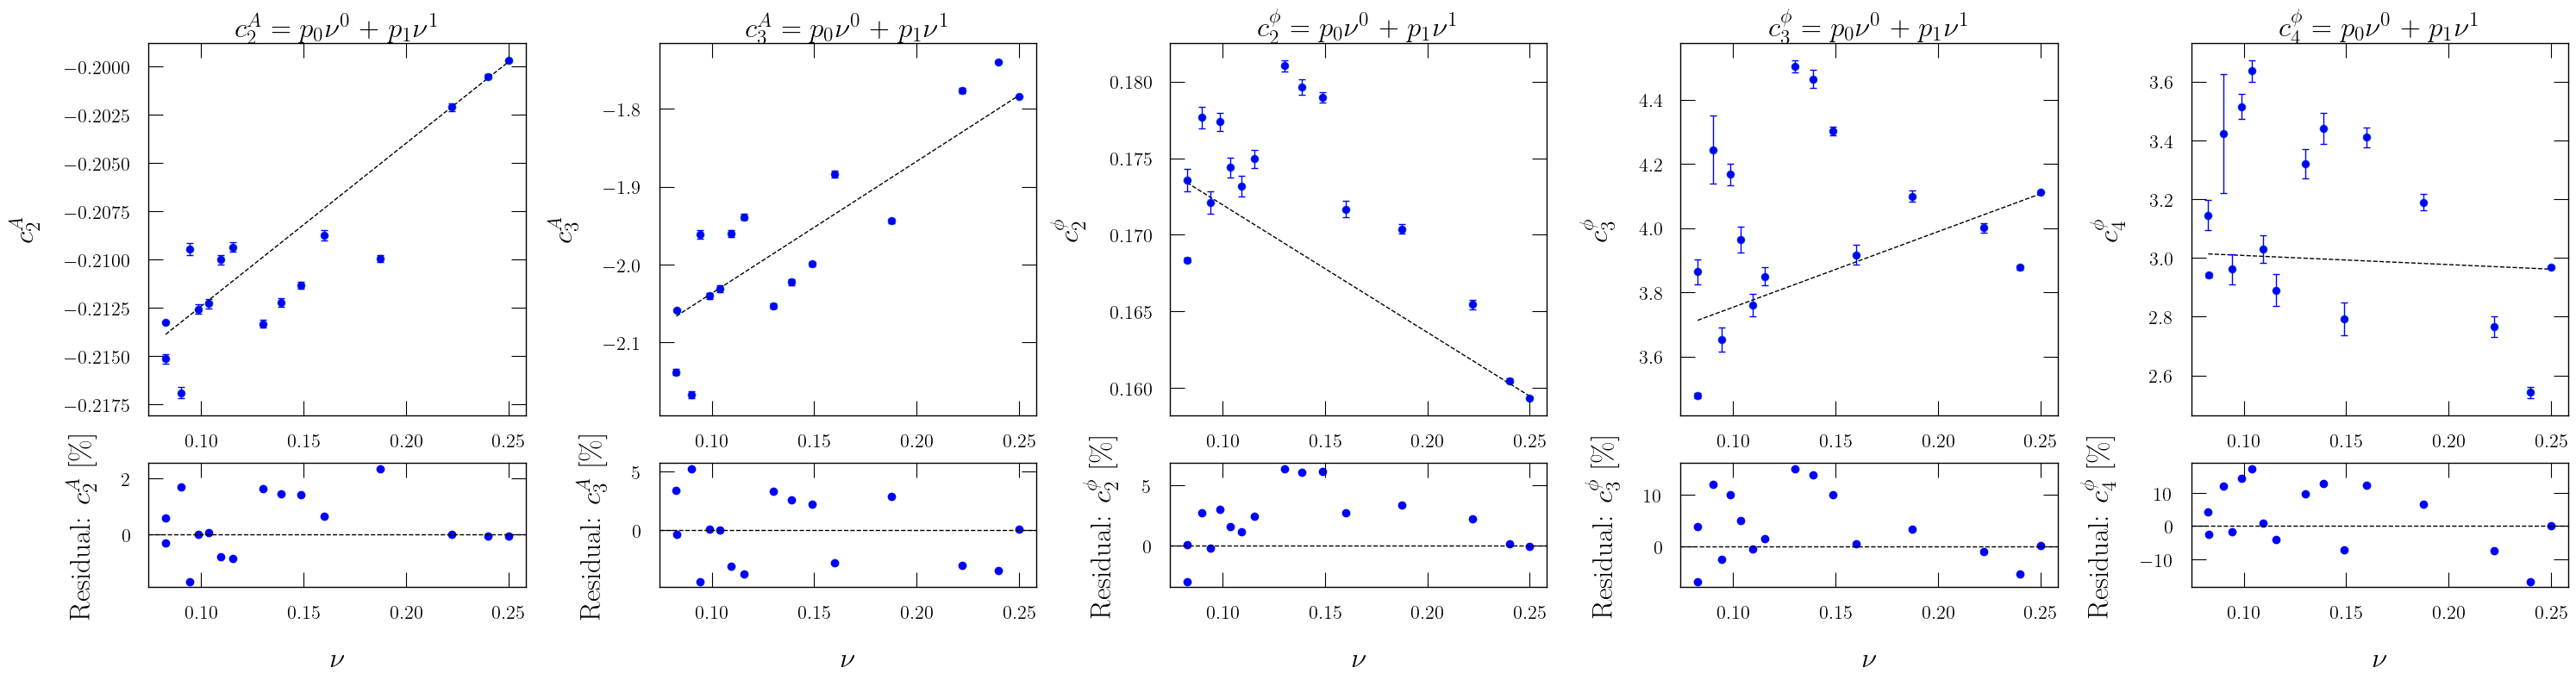

In [7]:
fig, ax = plt.subplots(2, 5, figsize=(30, 8), gridspec_kw={'height_ratios': [3, 1]})
plots, fits, errors = [c2A, c3A, c2p, c3p, c4p], [p2Anu, p3Anu, p2pnu, p3pnu, p4pnu], [c2A_err, c3A_err, c2p_err, c3p_err, c4p_err]
ylabels = ['$c_2^A$', '$c_3^A$', '$c_2^{\\phi}$', '$c_3^{\\phi}$', '$c_4^{\\phi}$']
nuspace = np.linspace(np.min(nu), np.max(nu), 100)
for i, (a_0, a_1, y, e, f, ylabel) in enumerate(zip(ax[0, :], ax[1, :],plots, errors, fits, ylabels)):    
    a_0.plot(nuspace, np.polyval(f, nuspace), label='Fit', color='k', linestyle='--')
    a_0.errorbar(nu, y, yerr=e, fmt='o', color='b', markersize=5, elinewidth=1, capsize=3)
    a_0.scatter(nu, y)
    a_0.set_ylabel(ylabel)
    poly_terms = []
    for j in range(len(f)):
        term = "$p_{{{}}} \\nu^{{{}}}$".format(j, j)
        poly_terms.append(term)
    poly_string = " $+$ ".join(poly_terms)
    a_0.set_title("{} = {}".format(ylabel, poly_string))
    residual = 100*(y - np.polyval(f, nu))/y
    a_1.axhline(0, color='k', linestyle='--')
    a_1.scatter(nu, residual, color='b', marker='o')
    a_1.set_xlabel('$\\nu$')
    a_1.set_ylabel('Residual: {ylabel} [\\%]'.format(ylabel=ylabel))
plt.tight_layout()
plt.show()

In [8]:
mismatch_real, mismatch_imag, mismatch = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
for i, sxs_id in enumerate(sxs_ids):
    try:
        mismatch_row = np.genfromtxt(f'../src/output/nc_fits_sxs_non-spinning/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
        mismatch_real[i] = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0]
        mismatch_imag[i] = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'imag']['Mismatch'][0]
        mismatch[i] = np.sqrt(mismatch_real[i]**2 + mismatch_imag[i]**2)
    except:
        continue

In [9]:
mismatch_real_global, mismatch_imag_global, mismatch_global = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
for i, sxs_id in enumerate(sxs_ids):
    try:
        mismatch_row = np.genfromtxt(f'../src/output/nc_global_fits_sxs_non-spinning/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                    dtype=None, names=True, encoding='utf-8', comments='#')
        mismatch_real_global[i] = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0]
        mismatch_imag_global[i] = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'imag']['Mismatch'][0]
        mismatch_global[i] = np.sqrt(mismatch_real_global[i]**2 + mismatch_imag_global[i]**2)
    except:
        continue

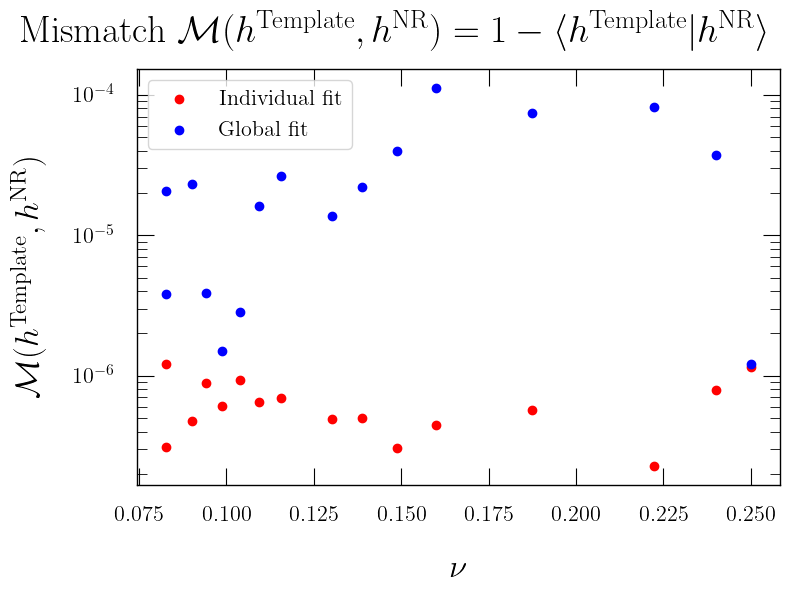

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.scatter(nu, mismatch, color='r', label='Individual fit')
ax.scatter(nu, mismatch_global, color='b', label='Global fit')
ax.set_xlabel('$\\nu$')
ax.set_ylabel('$\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})$')
ax.set_yscale('log')
ax.legend()
plt.suptitle('Mismatch $\\mathcal{M}(h^{\\rm Template}, h^{\\rm NR})=1-\\langle h^{\\rm Template}| h^{\\rm NR}\\rangle$')
plt.tight_layout()
plt.show()